# Image Orientation Detection - Automatic Detecion of Sagital vs Axial Images
In this notebook, we extract a subset of the full RSNA 2024 Lumbar Spine Degenerative Classification dataset, and use it to train a pair of models capable of classifying the orientation of an MRI image.

While we expect that most series of MRI images will have the image orientation pre-labeled as part of the associated metadata, it will be valuable to our end-to-end pipeline of models to be able to implement built-in verification of that label. This therefor represents a relatively simple problem, but one that will be important to deploying this series of models in a production environment.

## Create Custom Subset of Data for Sagital/Axial Classification Problem:

In [17]:
import pandas as pd
import os
import shutil

#!pip install tensorflow-io
import tensorflow_io as tfio
import tensorflow as tf
import random
from google.colab import files

In [ ]:
# Load Metadata CSV Files:
df_series_descriptions = pd.read_csv("train_series_descriptions.csv")
df_image_id_targets = pd.read_csv("train_label_coordinates.csv")

In [ ]:
# Build df to associate image orientation to each image:
df_image_id_targets['image_id'] = df_image_id_targets['study_id'].astype(str) + "_" + \
                                        df_image_id_targets['series_id'].astype(str) + "_" + \
                                        df_image_id_targets['instance_number'].astype(str)

df_image_id_targets = df_image_id_targets.merge(df_series_descriptions, on=['study_id', 'series_id'], how='left')

df_image_id_targets = df_image_id_targets.drop(['study_id', 'series_id', 'instance_number', 'condition', 'level', 'x', 'y'], axis=1)

df_image_id_targets['series_description'] = df_image_id_targets['series_description'].apply(lambda x: x.split(' ')[0] if isinstance(x, str) else x)

df_image_id_targets.drop_duplicates(inplace=True)
df_image_id_targets = df_image_id_targets.rename(columns={'series_description': 'orientation'})

df_image_id_targets.head()

,image_id,orientation
0,4003253_702807833_8,Sagittal
5,4003253_1054713880_4,Sagittal
7,4003253_1054713880_5,Sagittal
8,4003253_1054713880_6,Sagittal
10,4003253_1054713880_11,Sagittal


In [ ]:
# Sample 500 from each orientation
df_sagittal = df_image_id_targets[df_image_id_targets['orientation'] == 'Sagittal'].sample(n=500, random_state=47)
df_axial = df_image_id_targets[df_image_id_targets['orientation'] == 'Axial'].sample(n=500, random_state=47)

# Concatenate the two DataFrames and Shuffle
df_balanced_sample = pd.concat([df_sagittal, df_axial])
df_balanced_sample = df_balanced_sample.sample(frac=1, random_state=47).reset_index(drop=True)

df_balanced_sample['orientation'].value_counts()

,count
orientation,
Axial,500
Sagittal,500


In [10]:
# Save as csv:
#df_balanced_sample.to_csv('sag_ax_labels.csv', index=False)
df_balanced_sample = pd.read_csv("sag_ax_labels.csv")

In [5]:
# Import Full Dataset Directly from Kaggle:
#!pip install kaggle
#!mkdir ~/.kaggle
#!cp kaggle.json ~/.kaggle/
#!chmod 600 ~/.kaggle/kaggle.json

#!kaggle competitions download -c rsna-2024-lumbar-spine-degenerative-classification
#!unzip /content/rsna-2024-lumbar-spine-degenerative-classification.zip

100% 28.2G/28.2G [02:31<00:00, 239MB/s]
100% 28.2G/28.2G [02:31<00:00, 200MB/s]


In [ ]:
!unzip /content/rsna-2024-lumbar-spine-degenerative-classification.zip

In [ ]:
# Extract the images for our balanced sample from the larger dataset:

# Create the destination folder if it doesn't exist
if not os.path.exists('sag_ax_images'):
    os.makedirs('sag_ax_images')

# Iterate over the DataFrame and move the images
for _, row in df_balanced_sample.iterrows():
    image_id = row['image_id']
    folder_1, folder_2, filename = image_id.split('_', 2)
    source_path = os.path.join('train_images', folder_1, folder_2, filename + '.dcm')
    destination_path = os.path.join('sag_ax_images', image_id + '.dcm')

    if os.path.exists(source_path):
        shutil.copy(source_path, destination_path)
        print(f"Moved {source_path} to {destination_path}")
    else:
        print(f"Warning: {source_path} not found.")


In [ ]:
# Convert images from DCM to png format:
for filename in os.listdir('sag_ax_images'):
    if filename.endswith('.dcm'):
        # Load the DICOM file
        image_bytes = tf.io.read_file('sag_ax_images/' + filename)
        image = tfio.image.decode_dicom_image(image_bytes, dtype=tf.uint16)

        # Convert to 16-bit grayscale
        image = tf.image.convert_image_dtype(image, dtype=tf.uint16)
        image = tf.squeeze(image)  # Remove channel dimension if it exists

        # Add channel dimension if it doesn't exist
        if image.shape.rank == 2:  # Check if the image is 2D (grayscale)
            image = tf.expand_dims(image, axis=-1)  # Add channel dimension

        # Rescale pixel intensities to 0-255
        image = tf.cast(image, tf.float32)
        image = (image - tf.reduce_min(image)) / (tf.reduce_max(image) - tf.reduce_min(image)) * 255.0
        image = tf.cast(image, tf.uint8)

        # Check if the image is empty
        if image.shape.rank == 3: # Proceed only if image has data
            # Save as JPEG
            output_filename = filename.replace('.dcm', '.png')
            tf.io.write_file('sag_ax_images/' + output_filename, tf.image.encode_png(image))

            print(f"Converted {filename} to {output_filename}")
        else:
            print(f"Skipping {filename} as it appears to be empty.")

In [21]:
# Reorganize the directory sag_ax_images into train/val/test and sagital/axial subfolders:

os.makedirs('sag_ax_images/train/sagittal', exist_ok=True)
os.makedirs('sag_ax_images/train/axial', exist_ok=True)
os.makedirs('sag_ax_images/val/sagittal', exist_ok=True)
os.makedirs('sag_ax_images/val/axial', exist_ok=True)
os.makedirs('sag_ax_images/test/sagittal', exist_ok=True)
os.makedirs('sag_ax_images/test/axial', exist_ok=True)

# List all image files
image_files = [f for f in os.listdir('sag_ax_images') if f.endswith('.png')]

# Shuffle the image files randomly
random.shuffle(image_files)

# Split into train, val, and test sets
num_images = len(image_files)
num_train = int(0.8 * num_images)
num_val = int(0.1 * num_images)

train_files = image_files[:num_train]
val_files = image_files[num_train:num_train + num_val]
test_files = image_files[num_train + num_val:]

# Move images to respective folders
for file in train_files:
    image_id = file.rstrip('.png')
    orientation = df_balanced_sample.loc[df_balanced_sample['image_id'] == image_id, 'orientation'].values[0]
    src_path = os.path.join('sag_ax_images', file)
    dst_path = os.path.join('sag_ax_images', 'train', orientation.lower(), file)
    shutil.move(src_path, dst_path)

for file in val_files:
    image_id = file.rstrip('.png')
    orientation = df_balanced_sample.loc[df_balanced_sample['image_id'] == image_id, 'orientation'].values[0]
    src_path = os.path.join('sag_ax_images', file)
    dst_path = os.path.join('sag_ax_images', 'val', orientation.lower(), file)
    shutil.move(src_path, dst_path)

for file in test_files:
    image_id = file.rstrip('.png')
    orientation = df_balanced_sample.loc[df_balanced_sample['image_id'] == image_id, 'orientation'].values[0]
    src_path = os.path.join('sag_ax_images', file)
    dst_path = os.path.join('sag_ax_images', 'test', orientation.lower(), file)
    shutil.move(src_path, dst_path)

In [22]:
# Move all of the .dcm files in "sag_ax_iamges" to new folder "sag_ax_dcm"

# Create the destination folder if it doesn't exist
if not os.path.exists('sag_ax_dcm'):
    os.makedirs('sag_ax_dcm')

# Move .dcm files to the new folder
for filename in os.listdir('sag_ax_images'):
    if filename.endswith('.dcm'):
        src_path = os.path.join('sag_ax_images', filename)
        dst_path = os.path.join('sag_ax_dcm', filename)
        shutil.move(src_path, dst_path)


In [ ]:
# Save and download the new dataset and labels to return to later:

df_balanced_sample.to_csv('sag_ax_labels.csv', index=False)
files.download('sag_ax_labels.csv')

In [ ]:
!zip -r sag_ax_images.zip sag_ax_images
from google.colab import files
files.download('sag_ax_images.zip')

## Create TF Datasets:

In [25]:
!pip install tensorflow-io

import os
import shutil
import random

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow_io as tfio
import cv2
from tensorflow import keras

from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Flatten, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D, Activation, GlobalAveragePooling2D

from tqdm.keras import TqdmCallback
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import Accuracy

In [ ]:
# If needed, load images and labels created in previous section:
#df_balanced_sample = pd.read_csv('sag_ax_labels.csv')
#!unzip /content/sag_ax_images.zip

In [26]:
# Load Train, Validate, and Test Datasets as tf.data.Dataset objects:
(train) = keras.utils.image_dataset_from_directory(
    "/content/sag_ax_images/train",
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=20,
    image_size=(224, 224),
    shuffle=True,
    seed=47,
    interpolation="bilinear",
    #follow_links=False,
    #pad_to_aspect_ratio=True
)

(val) = keras.utils.image_dataset_from_directory(
    "/content/sag_ax_images/val",
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=20,
    image_size=(224, 224),
    shuffle=True,
    seed=47,
    interpolation="bilinear",
    #follow_links=False,
    #pad_to_aspect_ratio=True
)

(test) = keras.utils.image_dataset_from_directory(
    "/content/sag_ax_images/test",
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=20,
    image_size=(224, 224),
    shuffle=True,
    seed=47,
    interpolation="bilinear",
    follow_links=False,
    #pad_to_aspect_ratio=True
)

Found 799 files belonging to 2 classes.
Found 99 files belonging to 2 classes.
Found 101 files belonging to 2 classes.


## Build Champion - Basic CNN Model:

In [29]:
model_1 = Sequential([
    Conv2D(128, (3, 3), padding = 'same', input_shape=(224,224, 3), activation='relu', kernel_initializer='glorot_uniform'),
    #BatchNormalization()
    Conv2D(128, (3, 3), padding = 'same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), padding = 'same', activation='relu'),
    #BatchNormalization()
    Conv2D(128, (3, 3), padding = 'same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), padding = 'same', activation='relu'),
    #BatchNormalization()
    Conv2D(128, (3, 3), padding = 'same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), padding = 'same', activation='relu'),
    #BatchNormalization()
    Conv2D(128, (3, 3), padding = 'same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(2, activation='sigmoid')
])

# Compile the model:
opt = keras.optimizers.Adamax(learning_rate=0.005)
model_1.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy', 'precision', 'recall'])

In [ ]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 128)       │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 224, 224, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 128)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 401408)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │      25,690,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,136,577 (99.70 MB)

 Trainable params: 26,136,577 (99.70 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model_1_hist = model_1.fit(
  train,
  epochs=20,
  validation_data=val,
  verbose=1,
  callbacks=[
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=5, verbose=1),
    #ModelCheckpoint(filepath="model_1_best.h5", monitor="val_loss", save_best_only=True, verbose=1),
    TqdmCallback(verbose=1)
    ])

model_1.save('model_1.keras')

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - accuracy: 0.8615 - loss: 600.8407 - precision: 0.8453 - recall: 0.8551 - val_accuracy: 0.9899 - val_loss: 0.0543 - val_precision: 1.0000 - val_recall: 0.9596 - learning_rate: 0.0050
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9932 - loss: 0.0285 - precision: 0.9954 - recall: 0.9910 - val_accuracy: 0.9899 - val_loss: 0.0477 - val_precision: 0.9899 - val_recall: 0.9899 - learning_rate: 0.0050
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9993 - loss: 0.0064 - precision: 0.9993 - recall: 0.9993 - val_accuracy: 0.9899 - val_loss: 0.1715 - val_precision: 0.9899 - val_recall: 0.9899 - learning_rate: 0.0050
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9938 - loss: 0.1509 - precision: 0.9938 - recall: 0.9938 - val_accuracy: 0.9899 - val_loss: 0.0252 - val_precision: 0.9899 - val_recall: 0.9899 - learning_rate: 0.0050
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 1.

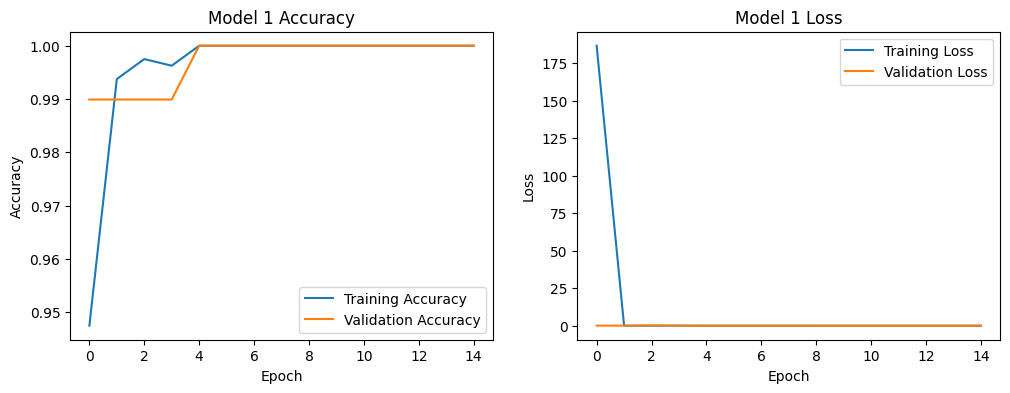

In [31]:
# Create Accuracy and Loss Plots:

# Create a figure to display accuracy and loss plots
plt.figure(figsize=(12, 4))

# Plot the accuracy for training and validation
plt.subplot(1, 2, 1)
plt.plot(model_1_hist.history['accuracy'], label='Training Accuracy')
plt.plot(model_1_hist.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model 1 Accuracy')
plt.legend()

# Plot the loss for training and validation
plt.subplot(1, 2, 2)
plt.plot(model_1_hist.history['loss'], label='Training Loss')
plt.plot(model_1_hist.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model 1 Loss')
plt.legend()

# Show the plot
plt.show()

In [32]:
# Evaluate Model:
#model_1_loaded = keras.models.load_model('model_1.keras')
#model_1_loaded.evaluate(test)

model_1.evaluate(test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - accuracy: 0.9940 - loss: 0.0365 - precision: 0.9754 - recall: 0.9940


[0.04630502685904503,
 0.9900990128517151,
 0.9803921580314636,
 0.9900990128517151]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step


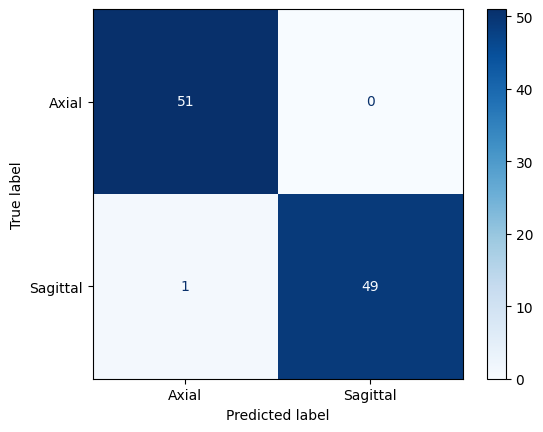

In [33]:
y_true = []
y_pred = []
for images, labels in test:
  predictions = model_1.predict(images)
  y_true.extend(np.argmax(labels, axis=1))
  y_pred.extend(np.argmax(predictions, axis=1))

# Create the confusion matrix
confusion_matrix_1 = confusion_matrix(y_true, y_pred)

# Display the confusion matrix
cm_disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_1, display_labels=['Axial', 'Sagittal'])
cm_disp.plot(cmap=plt.cm.Blues)
plt.show()

## Build Challenger - Transfer Learning with EfficientNet:

In [37]:
base_model = keras.applications.ResNet101(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

for layer in base_model.layers[-3:]:
  layer.trainable = True

In [38]:
# Add additional laters to base model:
transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='sigmoid')
])

# Compile the model:
transfer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'precision', 'recall'])

In [39]:
transfer_model_hist = transfer_model.fit(
  train,
  epochs=5,
  validation_data=val,
  verbose=1,
  callbacks=[
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=5, verbose=1),
    ModelCheckpoint(filepath="tr_model_best.keras", monitor="val_loss", save_best_only=True, verbose=1),
    TqdmCallback(verbose=1)
    ])

transfer_model.save('transfer_model.keras')

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9503 - loss: 0.1840 - precision: 0.9282 - recall: 0.8963
Epoch 1: val_loss improved from inf to 0.00000, saving model to tr_model_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 36s 446ms/step - accuracy: 0.9511 - loss: 0.1808 - precision: 0.9294 - recall: 0.8976 - val_accuracy: 1.0000 - val_loss: 1.0115e-07 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 4.1471e-05 - precision: 1.0000 - recall: 0.9799
Epoch 2: val_loss did not improve from 0.00000
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 1.0000 - loss: 4.2031e-05 - precision: 1.0000 - recall: 0.9798 - val_accuracy: 1.0000 - val_loss: 1.4088e-07 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 2.9900e-05 - precision: 1.0000 - recall: 0.9817
Epoch 3: val_loss did not improve from 

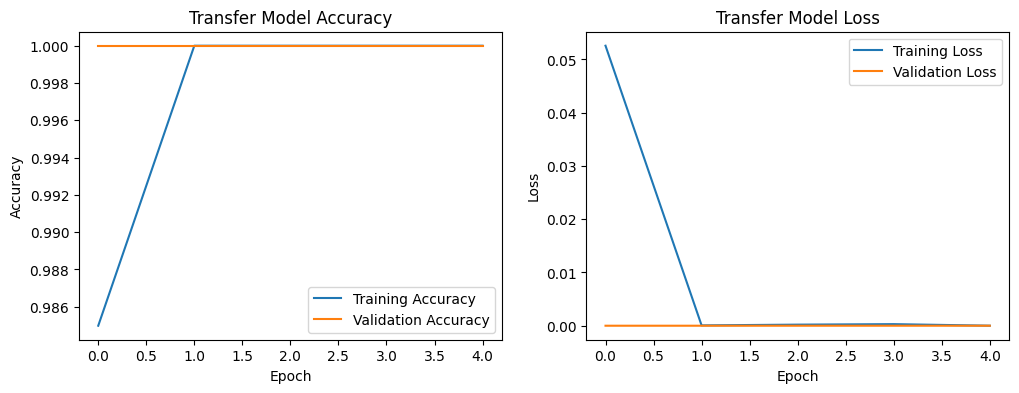

In [40]:
# Create Accuracy and Loss Plots:

# Create a figure to display accuracy and loss plots
plt.figure(figsize=(12, 4))

# Plot the accuracy for training and validation
plt.subplot(1, 2, 1)
plt.plot(transfer_model_hist.history['accuracy'], label='Training Accuracy')
plt.plot(transfer_model_hist.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Transfer Model Accuracy')
plt.legend()

# Plot the loss for training and validation
plt.subplot(1, 2, 2)
plt.plot(transfer_model_hist.history['loss'], label='Training Loss')
plt.plot(transfer_model_hist.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transfer Model Loss')
plt.legend()

# Show the plot
plt.show()

In [41]:
transfer_model_eval = transfer_model.evaluate(test, verbose=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 763ms/step - accuracy: 1.0000 - loss: 3.5097e-04 - precision: 1.0000 - recall: 0.9880


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


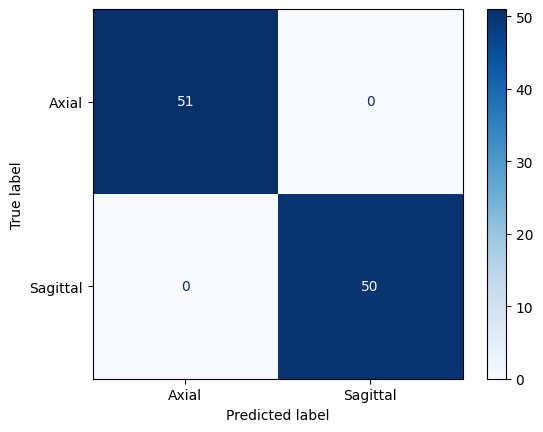

In [44]:
# Extract true labels and predictions
y_true = []
y_pred = []
for images, labels in test:
  predictions = transfer_model.predict(images)
  y_true.extend(np.argmax(labels, axis=1))
  y_pred.extend(np.argmax(predictions, axis=1))

# Create the confusion matrix
confusion_matrix_tr = confusion_matrix(y_true, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_tr, display_labels=['Axial', 'Sagittal'])
disp.plot(cmap=plt.cm.Blues)
plt.show()
